In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = pd.read_csv("../datasets/vgsales_clean.csv")

data.head()
data.sort_values(by='Ventas_Globales', ascending=False).head()

,Nombre,Plataforma,Año,Género,Publicador,Ventas_Norteamérica,Ventas_Europa,Ventas_Japón,Ventas_Otros,Ventas_Globales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Para empezar a realizar la practica buscamos datos que tengan un grado de correlacion alto, para esto realizamos la siguiente grafica de calor de la matriz de correlacion.
Cada recuadro en la matriz nos indica el nivel de correlacion que hay entre las variables reglones y columnas, entre mas pegado este al -1 o 1 el grado de correlacion es mayor.

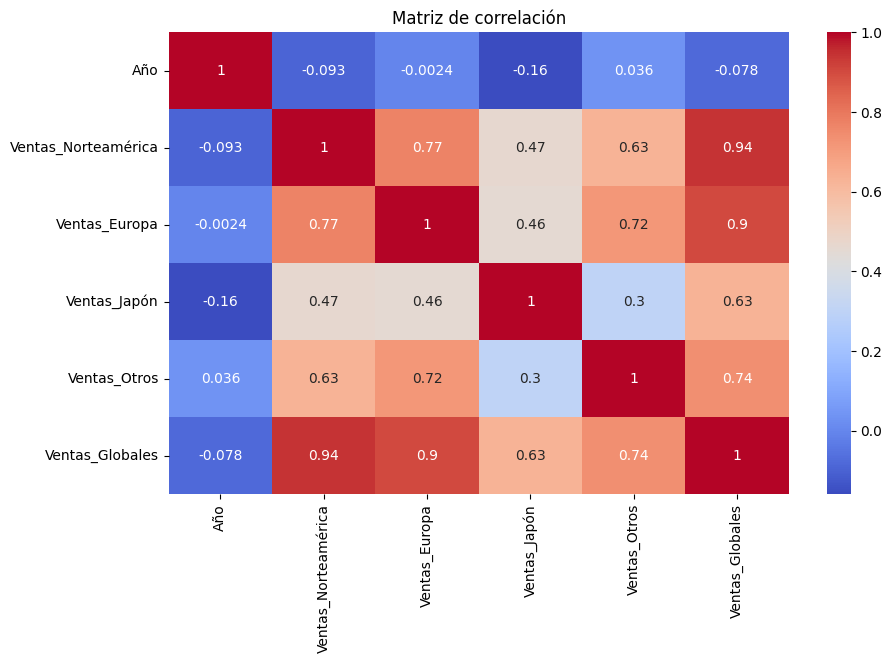

In [2]:
def mostrar_correlacion(data):
    """Muestra un mapa de calor con las correlaciones entre variables numéricas."""
    corr = data.corr(numeric_only=True)
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Matriz de correlación')
    plt.show()

mostrar_correlacion(data)


A pesar de que es una eleccion obvia, elegimos realizar la regresion lineal con las variables de ventas de norteamerica y ventas globales ya que tienen el mayor grado de correlacion. 
Menciono que la eleccion es obvia porque claramente las ventas de norteamerica afectan a las ventas globales, pero nos sirve para probar los metodos de sklear y crear la grafica. 

R² Score: 0.8866   ---   El modelo predice con exito la variable dependiente



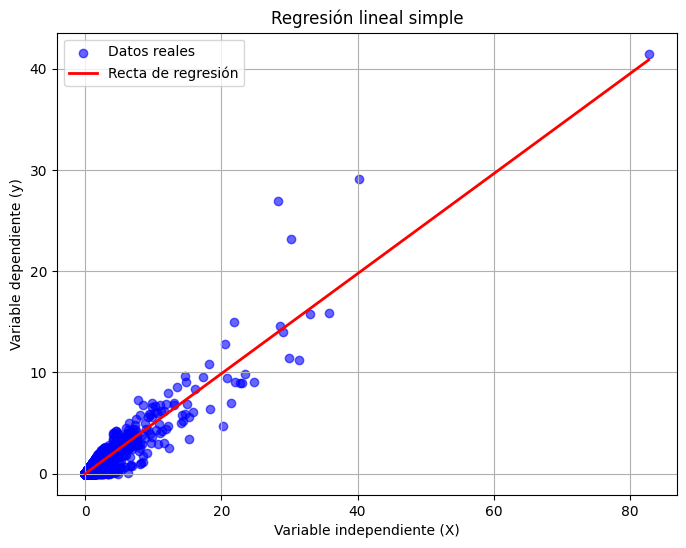

In [7]:
def modelo_lineal_simple(X, y):
    """Imprime un grafico de la regresion lineal junto a los datos originales, aparte de 
    retornar el modelo de regresion"""
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)

    # Crear y entrenar el modelo
    modelo = LinearRegression()
    modelo.fit(X, y)

    # Predicciones
    y_pred = modelo.predict(X)

    # Calcular R²
    r2 = r2_score(y, y_pred)

    if r2 > 0.80:
        print(f"R² Score: {r2:.4f}   ---   El modelo predice con exito la variable dependiente", end="\n\n")
    else:
        print(f"R² Score: {r2:.4f}   ---   El modelo no predice con exito la variable dependiente", end="\n\n")
    
    

    # Graficar la recta de regresión junto con los datos originales
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', label='Datos reales', alpha=0.6)
    plt.plot(X, y_pred, color='red', linewidth=2, label='Recta de regresión')
    plt.xlabel('Variable independiente (X)')
    plt.ylabel('Variable dependiente (y)')
    plt.title('Regresión lineal simple')
    plt.legend()
    plt.grid(True)
    plt.show()

    return modelo


#elegimos usar como variable x ventas_norteamerica ya que era la que contaba con mayor correlacion
#hacia la variable de ventas globales


X = data['Ventas_Globales']  # variable independiente
y = data['Ventas_Norteamérica']      # variable dependiente
#uso del modelo
modelo = modelo_lineal_simple(X, y)

Es deseable un valor de R2 Score cercano a un 1 nos indica que el modelo ajusta a la perfeccion la mayoria de los datos dentro de la linea con una valor de significancia alto, mientras que si R2 score se acera a 0, este nos indica que el modelo falla para predecir la mayoria de los datos. 

por cierto cabe mencionar que podra ver una dato atipico hasta arriba de la grafica, sin embargo, ya se hizo la revision y no es un dato atipico sino que son las ventas del juego wii sports, que para el caso de este data set en especifico, supera a su segundo lugar casi por el doble de ventas siendo de lejos el juego mas vendido registrado. 